In [63]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten


In [64]:
data = pd.read_csv("creditcard.csv")

In [65]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [67]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [68]:
data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [69]:
## DAtaset is highly unbalanced
# 0 -> Normal Transaction
# 1-> frudulent transaction

## Separating the data for anaylytics 
legit = data[data.Class == 0]
fraud = data[data.Class == 1]

In [70]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [71]:
## Statisticl measure of data

legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [72]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [73]:
# Compare the valus for both transactions

data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,-0.006576,0.010832,0.000189,0.012064,0.000161,0.007164,0.011535,0.003887,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [74]:
# Under sampling
## Build a sample data set containing the smilar distribution of the legit transaction adn fraud transaction

# No of fraud transaction = 492

legit_sample = legit.sample(n = 492)




In [75]:
## Concatinating two dataframes

new_data = pd.concat([legit_sample, fraud], axis=0)

In [76]:
new_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
224868,144003.0,1.930321,-0.099410,-2.112190,0.070807,0.853817,0.074166,0.106588,-0.060797,0.591576,-0.750204,0.697447,1.445522,1.375388,-1.581420,-0.825139,0.341223,0.461508,0.579018,0.658793,0.087191,-0.201174,-0.439086,0.038898,-0.283132,0.054355,-0.093272,-0.015100,-0.020683,68.00,0
216522,140515.0,1.945640,-0.292605,-2.208134,0.107600,0.575090,-0.209431,0.017442,-0.018825,0.998513,-0.667253,-0.172637,0.041952,-0.937577,-1.125372,-0.619302,0.625596,0.390538,1.082828,0.913992,-0.057913,-0.255471,-0.693792,-0.041768,-1.524181,0.031423,-0.027156,-0.031004,-0.035782,76.00,0
238413,149657.0,-0.079169,0.510758,0.532724,-0.526172,0.852134,-1.171540,1.225988,-0.478885,-0.032452,-0.417342,-1.011553,-0.027696,-0.199035,-0.008756,-0.667579,-0.401476,-0.383685,-0.732123,0.108368,-0.042052,-0.145144,-0.197306,0.049225,0.059374,-0.892023,0.115198,-0.024533,-0.011090,11.10,0
21931,31942.0,1.299990,-0.489392,0.147205,-0.519234,-0.929233,-0.695255,-0.729257,0.023396,-0.545552,0.151894,0.104246,-1.348049,-1.067797,-1.053633,1.373702,1.384389,1.375840,-1.138998,-0.046374,0.048353,0.075076,0.060547,0.022721,-0.032827,0.240476,-0.251537,0.032875,0.043912,34.90,0
106079,69813.0,1.168353,-0.310955,0.717942,-0.990310,-0.889064,-0.473789,-0.519678,0.145698,1.200089,-0.856280,1.897113,1.301699,-0.399184,0.481572,1.528952,-0.363022,-0.243993,0.209920,0.269381,-0.156296,0.046503,0.229375,0.058709,0.203145,0.297455,-0.808063,0.087298,0.022918,3.77,0


In [77]:
new_data['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [78]:
new_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,96573.371951,0.094020,0.066756,0.037911,-0.058453,-0.099034,-0.067683,-0.058277,0.078326,0.046176,0.001523,-0.043217,-0.086175,-0.116713,0.020053,-0.010267,0.030056,-0.021067,-0.026443,0.011051,0.016466,-0.010104,0.059857,0.009204,0.065184,0.037976,0.021060,0.000578,0.018836,71.315854
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [79]:
## splitting data into labels and target
X = new_data.drop(columns=['Class', 'Time'], axis=1)
Y = new_data['Class']

In [80]:
print(X)

              V1        V2        V3  ...       V27       V28  Amount
224868  1.930321 -0.099410 -2.112190  ... -0.015100 -0.020683   68.00
216522  1.945640 -0.292605 -2.208134  ... -0.031004 -0.035782   76.00
238413 -0.079169  0.510758  0.532724  ... -0.024533 -0.011090   11.10
21931   1.299990 -0.489392  0.147205  ...  0.032875  0.043912   34.90
106079  1.168353 -0.310955  0.717942  ...  0.087298  0.022918    3.77
...          ...       ...       ...  ...       ...       ...     ...
279863 -1.927883  1.125653 -4.518331  ...  0.292680  0.147968  390.00
280143  1.378559  1.289381 -5.004247  ...  0.389152  0.186637    0.76
280149 -0.676143  1.126366 -2.213700  ...  0.385107  0.194361   77.89
281144 -3.113832  0.585864 -5.399730  ...  0.884876 -0.253700  245.00
281674  1.991976  0.158476 -2.583441  ...  0.002988 -0.015309   42.53

[984 rows x 29 columns]


In [81]:
print(Y)

224868    0
216522    0
238413    0
21931     0
106079    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


In [82]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2, random_state=42)
for train_index , test_index in split.split(X , Y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    Y_train = Y.iloc[train_index]
    Y_test = Y.iloc[test_index]

In [83]:
print(X_train.shape)
print(Y_train.shape)

(787, 29)
(787,)


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [85]:
model = Sequential([
    tf.keras.Input(shape=(29,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [86]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [87]:
history = model.fit(X_train, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5734 - loss: 0.6764 - val_accuracy: 0.7722 - val_loss: 0.5846
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8418 - loss: 0.4883 - val_accuracy: 0.7975 - val_loss: 0.4640
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8842 - loss: 0.3850 - val_accuracy: 0.8608 - val_loss: 0.3905
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8969 - loss: 0.3211 - val_accuracy: 0.8608 - val_loss: 0.3349
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9124 - loss: 0.2784 - val_accuracy: 0.8608 - val_loss: 0.2950
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9124 - loss: 0.2455 - val_accuracy: 0.8987 - val_loss: 0.2655
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9181 - loss: 0.2205 - val_accuracy: 0.9114 - val_loss: 0.2451
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9237 - loss: 0.2023 - val_accuracy: 0.9241 - val_lo

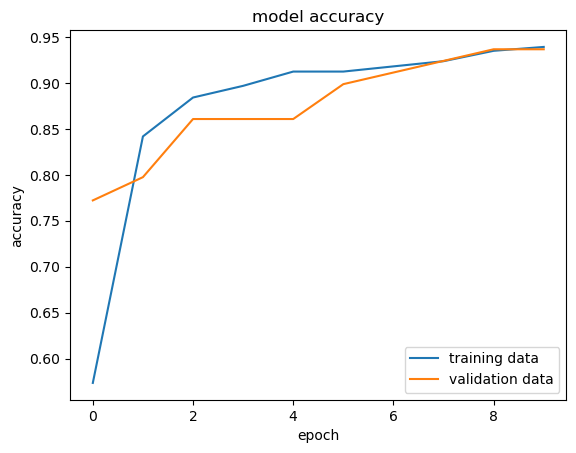

In [88]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')
plt.show()


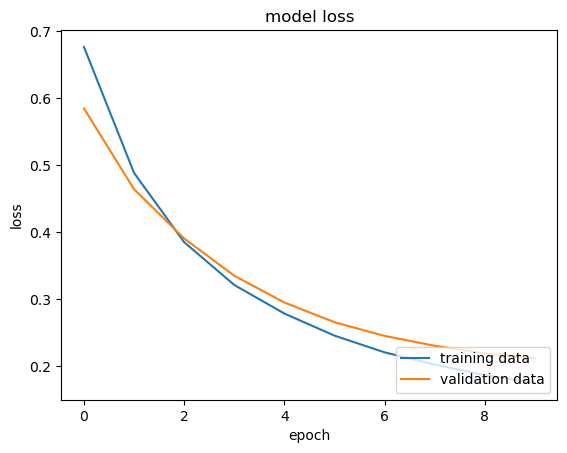

In [89]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')
plt.show()


In [90]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9645 - loss: 0.1330 
0.9644669890403748


In [91]:
Y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [92]:
y_pred_labels = [np.argmax(i) for i in Y_pred]
y_pred_labels

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.in

In [93]:
## Building a Predictive model

input_data = [ -0.966271711572087, -0.185226008082898, 1.79299333957872,
    -0.863291275036453, -0.0103088796030823, 1.24720316752486,
    0.23760893977178, 0.377435874652262, -1.38702406270197,
    -0.0549519224713749, -0.226487263835401, 0.178228225877303,
    0.507756869957169, -0.28792374549456, -0.631418117709045,
    -1.0596472454325, -0.684092786345479, 1.96577500349538,
    -1.2326219700892, -0.208037781160366, -0.108300452035545,
    0.00527359678253453, -0.190320518742841, -1.17557533186321,
    0.647376034602038, -0.221928844458407, 0.0627228487293033,
    0.0614576285006353, 123.5]

input_data_as_np_array = np.asarray(input_data)

input_data_reshaped = input_data_as_np_array.reshape(1, -1)

input_data_std = scaler.transform(input_data_reshaped)


Prediction = model.predict(input_data_std)

prediction_label = [np.argmax(Prediction)]



if prediction_label[0] == 0:
    print("Model Prediction: Legit Transaction")
else:
    print("Model Prediction: Fraudulent Transaction")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Model Prediction: Legit Transaction


d:\HP\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
